# Data Exploration for HMM Research Environment

This notebook provides comprehensive data exploration and preprocessing for LDC signal data analysis. It serves as the foundation for Hidden Markov Model training and regime detection research.

## Objectives
- Load and explore LDC signal data from the Rust engine
- Perform data quality assessment and preprocessing
- Visualize signal characteristics and relationships
- Prepare data for HMM training workflows

## Setup and Imports

In [1]:
# Setup notebook environment
import sys
from pathlib import Path

# Add utils to path
sys.path.append('utils')

from utils.notebook_utils import setup_notebook_environment, check_dependencies
from utils.data_loaders import (
    load_ldc_signals, load_sample_data, preprocess_signals, 
    create_multivariate_observations, load_rust_ldc_output
)
from utils.plotting_helpers import (
    create_interactive_plot, plot_signal_correlation, 
    plot_signal_distributions, create_diagnostic_plots
)

# Setup environment
project_root = setup_notebook_environment()
check_dependencies()

✓ Notebook environment configured
✓ Project root: /home/nipung2010/fictional-enigma
🔍 Checking dependencies...
✓ All required dependencies available


True

In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Data Loading

Load LDC signal data from the Rust engine output. If real data is not available, we'll generate sample data for demonstration.

In [3]:
# Configuration
DATA_PATH = project_root / "rust" / "sample"  # Adjust path as needed
USE_SAMPLE_DATA = True  # Set to False when real LDC data is available

print(f"Looking for data in: {DATA_PATH}")
print(f"Data path exists: {DATA_PATH.exists()}")

Looking for data in: /home/nipung2010/fictional-enigma/rust/sample
Data path exists: True


In [4]:
# Load data
try:
    if USE_SAMPLE_DATA or not DATA_PATH.exists():
        print("📊 Loading sample data for demonstration...")
        df_signals = load_sample_data(n_samples=2000, n_features=3, random_state=42)
        data_source = "Sample Data"
    else:
        print("📊 Loading real LDC signal data...")
        df_signals = load_rust_ldc_output(DATA_PATH)
        data_source = "LDC Engine Output"
        
except Exception as e:
    print(f"⚠️  Error loading data: {e}")
    print("📊 Falling back to sample data...")
    df_signals = load_sample_data(n_samples=2000, n_features=3, random_state=42)
    data_source = "Sample Data (Fallback)"

print(f"\n✅ Data loaded successfully!")
print(f"   Source: {data_source}")
print(f"   Shape: {df_signals.shape}")
print(f"   Columns: {list(df_signals.columns)}")
print(f"   Date range: {df_signals.index.min()} to {df_signals.index.max()}")

📊 Loading sample data for demonstration...
✓ Generated sample data: 2000 rows, 3 columns
✓ Date range: 2024-01-01 00:00:00 to 2024-01-07 22:35:00

✅ Data loaded successfully!
   Source: Sample Data
   Shape: (2000, 3)
   Columns: ['s_signal_1', 's_signal_2', 's_signal_3']
   Date range: 2024-01-01 00:00:00 to 2024-01-07 22:35:00


## Data Quality Assessment

In [5]:
# Basic data info
print("📋 Data Information:")
print(f"   Shape: {df_signals.shape}")
print(f"   Memory usage: {df_signals.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Index type: {type(df_signals.index)}")
print(f"   Frequency: {df_signals.index.freq}")

# Display basic statistics
print("\n📊 Descriptive Statistics:")
display(df_signals.describe())

📋 Data Information:
   Shape: (2000, 3)
   Memory usage: 0.06 MB
   Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   Frequency: <5 * Minutes>

📊 Descriptive Statistics:


,s_signal_1,s_signal_2,s_signal_3
count,2000.000000,2000.000000,2000.000000
mean,0.442146,0.324643,0.265445
std,1.743762,1.764818,1.856809
min,-6.543038,-7.115704,-6.033760
25%,-0.504603,-0.622575,-0.689574
50%,0.360123,0.296262,0.252490
75%,1.514838,1.465721,1.441722
max,8.204398,6.552210,7.633912


In [6]:
# Check for missing values and data quality issues
print("🔍 Data Quality Check:")
print(f"   Missing values: {df_signals.isnull().sum().sum()}")
print(f"   Infinite values: {np.isinf(df_signals.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Duplicate timestamps: {df_signals.index.duplicated().sum()}")

if df_signals.isnull().sum().sum() > 0:
    print("\n⚠️  Missing values by column:")
    missing_data = df_signals.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    for col, count in missing_data.items():
        percentage = (count / len(df_signals)) * 100
        print(f"   {col}: {count} ({percentage:.2f}%)")

🔍 Data Quality Check:
   Missing values: 0
   Infinite values: 0
   Duplicate timestamps: 0


## Signal Visualization

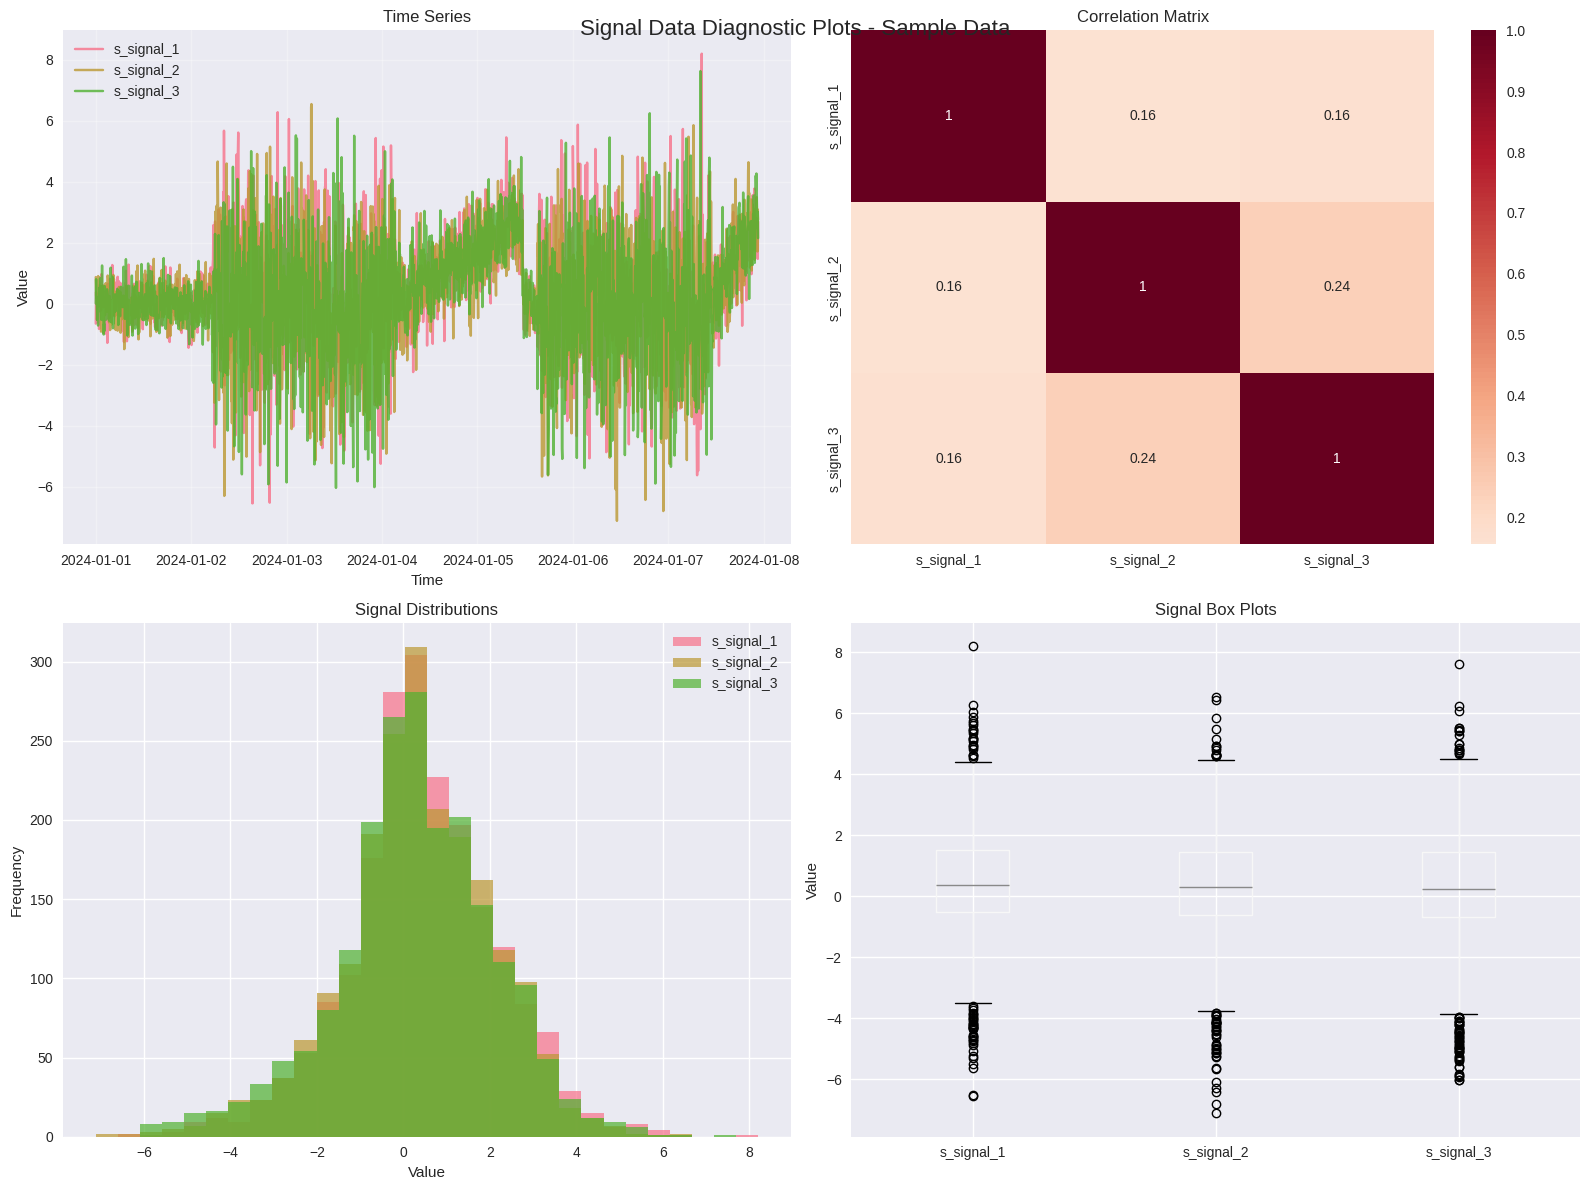

In [7]:
# Create comprehensive diagnostic plots
fig = create_diagnostic_plots(df_signals, figsize=(16, 12))
plt.suptitle(f'Signal Data Diagnostic Plots - {data_source}', fontsize=16, y=0.98)
plt.show()

In [8]:
# Interactive time series plot (if plotly is available)
try:
    interactive_fig = create_interactive_plot(
        df_signals, 
        title=f"Interactive Signal Data - {data_source}",
        height=600
    )
    interactive_fig.show()
except Exception as e:
    print(f"Interactive plot not available: {e}")
    # Fallback to matplotlib
    fig, ax = plt.subplots(figsize=(15, 6))
    for col in df_signals.columns:
        ax.plot(df_signals.index, df_signals[col], label=col, alpha=0.8)
    ax.set_title(f'Signal Time Series - {data_source}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal Value')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

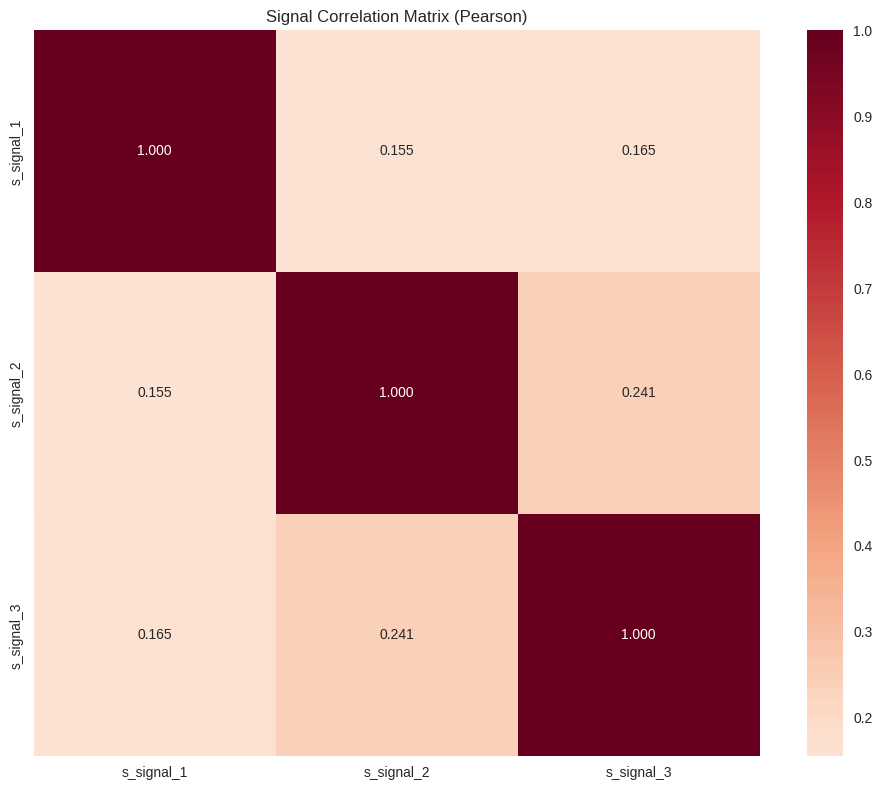


🔗 Signal Correlations:
   s_signal_1 ↔ s_signal_2: 0.155
   s_signal_1 ↔ s_signal_3: 0.165
   s_signal_2 ↔ s_signal_3: 0.241


In [9]:
# Signal correlation analysis
fig = plot_signal_correlation(df_signals, method='pearson', figsize=(10, 8))
plt.show()

# Print correlation summary
corr_matrix = df_signals.corr()
print("\n🔗 Signal Correlations:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        print(f"   {col1} ↔ {col2}: {corr_val:.3f}")

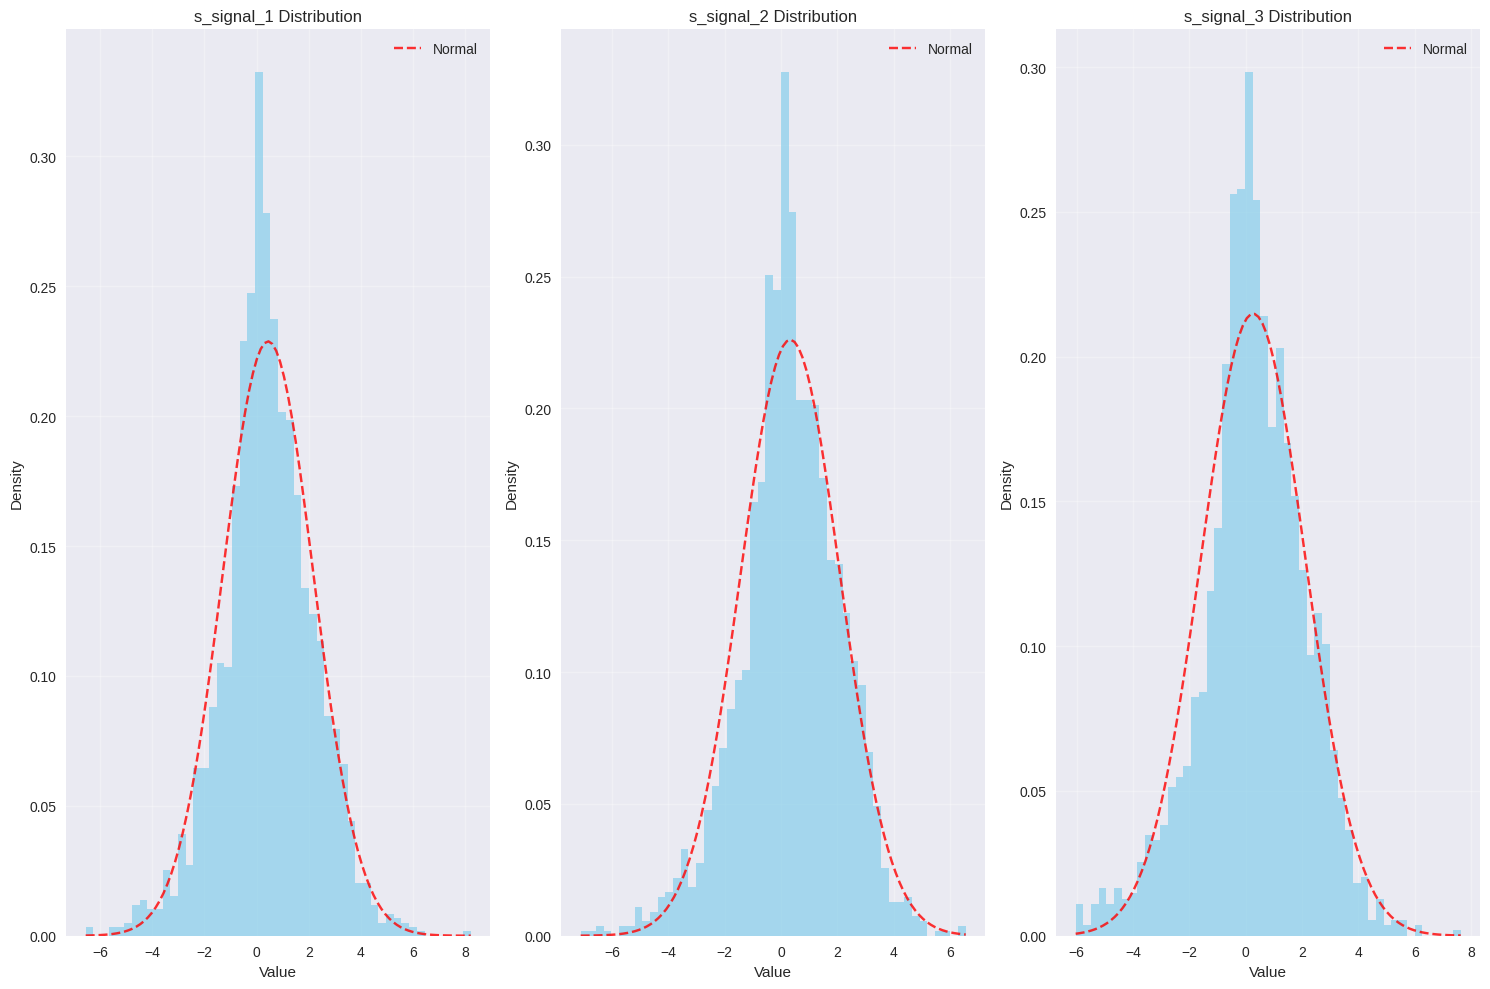


📈 Normality Tests (Shapiro-Wilk):
   s_signal_1: p-value = 0.000000 ✗ Non-normal
   s_signal_2: p-value = 0.000000 ✗ Non-normal
   s_signal_3: p-value = 0.000000 ✗ Non-normal


In [10]:
# Signal distributions
fig = plot_signal_distributions(df_signals, figsize=(15, 10))
plt.show()

# Statistical tests for normality
from scipy import stats

print("\n📈 Normality Tests (Shapiro-Wilk):")
for col in df_signals.columns:
    # Use sample for large datasets
    sample_size = min(5000, len(df_signals))
    sample_data = df_signals[col].dropna().sample(sample_size, random_state=42)
    
    statistic, p_value = stats.shapiro(sample_data)
    is_normal = p_value > 0.05
    print(f"   {col}: p-value = {p_value:.6f} {'✓ Normal' if is_normal else '✗ Non-normal'}")

## Data Preprocessing

In [11]:
# Preprocessing options
PREPROCESSING_METHOD = 'standardize'  # 'standardize', 'normalize', 'none'
HANDLE_MISSING = 'forward_fill'       # 'forward_fill', 'drop', 'interpolate'
OUTLIER_THRESHOLD = 3.0               # Z-score threshold for outlier removal

print(f"🔧 Preprocessing Configuration:")
print(f"   Method: {PREPROCESSING_METHOD}")
print(f"   Missing values: {HANDLE_MISSING}")
print(f"   Outlier threshold: {OUTLIER_THRESHOLD} std devs")

🔧 Preprocessing Configuration:
   Method: standardize
   Missing values: forward_fill
   Outlier threshold: 3.0 std devs


In [12]:
# Apply preprocessing
df_processed = preprocess_signals(
    df_signals,
    method=PREPROCESSING_METHOD,
    handle_missing=HANDLE_MISSING,
    outlier_threshold=OUTLIER_THRESHOLD
)

print("\n📊 Preprocessing Results:")
print(f"   Original shape: {df_signals.shape}")
print(f"   Processed shape: {df_processed.shape}")
print(f"   Data preserved: {(df_processed.shape[0] / df_signals.shape[0]) * 100:.1f}%")

🔧 Preprocessing signals...
   Input shape: (2000, 3)
   Removing 15 outliers from s_signal_1
   Removing 18 outliers from s_signal_2
   Removing 15 outliers from s_signal_3
   ✓ Applied standardization (z-score)
   Output shape: (2000, 3)

📊 Preprocessing Results:
   Original shape: (2000, 3)
   Processed shape: (2000, 3)
   Data preserved: 100.0%


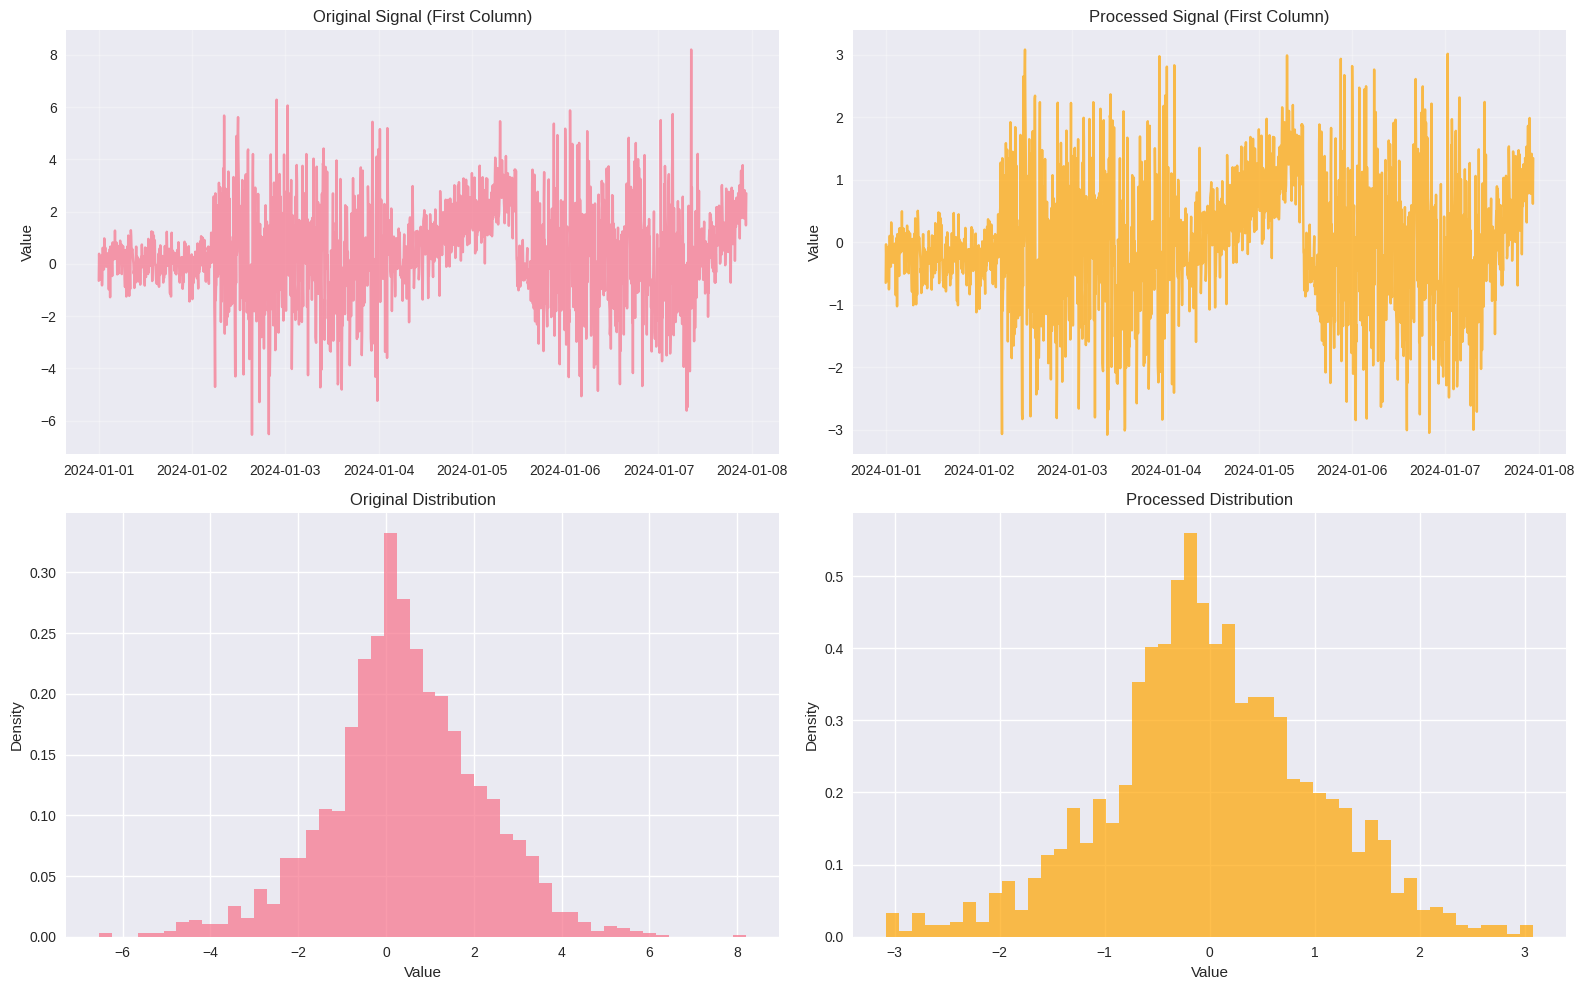


📊 Statistical Comparison:
Original Data:
       s_signal_1  s_signal_2  s_signal_3
count   2000.0000   2000.0000   2000.0000
mean       0.4421      0.3246      0.2654
std        1.7438      1.7648      1.8568
min       -6.5430     -7.1157     -6.0338
25%       -0.5046     -0.6226     -0.6896
50%        0.3601      0.2963      0.2525
75%        1.5148      1.4657      1.4417
max        8.2044      6.5522      7.6339

Processed Data:
       s_signal_1  s_signal_2  s_signal_3
count   2000.0000   2000.0000   2000.0000
mean      -0.0000     -0.0000     -0.0000
std        1.0000      1.0000      1.0000
min       -3.0839     -3.1193     -3.0897
25%       -0.5651     -0.5700     -0.5361
50%       -0.0525     -0.0292     -0.0163
75%        0.6348      0.6611      0.6402
max        3.0823      3.0464      2.9244


In [13]:
# Compare before and after preprocessing
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original data
axes[0, 0].plot(df_signals.index, df_signals.iloc[:, 0], alpha=0.7, label='Original')
axes[0, 0].set_title('Original Signal (First Column)')
axes[0, 0].set_ylabel('Value')
axes[0, 0].grid(True, alpha=0.3)

# Processed data
axes[0, 1].plot(df_processed.index, df_processed.iloc[:, 0], alpha=0.7, label='Processed', color='orange')
axes[0, 1].set_title('Processed Signal (First Column)')
axes[0, 1].set_ylabel('Value')
axes[0, 1].grid(True, alpha=0.3)

# Distribution comparison
axes[1, 0].hist(df_signals.iloc[:, 0].dropna(), bins=50, alpha=0.7, label='Original', density=True)
axes[1, 0].set_title('Original Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Density')

axes[1, 1].hist(df_processed.iloc[:, 0].dropna(), bins=50, alpha=0.7, label='Processed', color='orange', density=True)
axes[1, 1].set_title('Processed Distribution')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Statistical comparison
print("\n📊 Statistical Comparison:")
print("Original Data:")
print(df_signals.describe().round(4))
print("\nProcessed Data:")
print(df_processed.describe().round(4))

## Prepare Data for HMM Training

In [14]:
# Create multivariate observations for HMM training
observations = create_multivariate_observations(df_processed)

print(f"✅ HMM Training Data Prepared:")
print(f"   Observations shape: {observations.shape}")
print(f"   Features: {list(df_processed.columns)}")
print(f"   Data type: {observations.dtype}")
print(f"   Memory usage: {observations.nbytes / 1024**2:.2f} MB")

# Validate observations
print(f"\n🔍 Observation Validation:")
print(f"   Contains NaN: {np.isnan(observations).any()}")
print(f"   Contains Inf: {np.isinf(observations).any()}")
print(f"   Min value: {np.min(observations):.4f}")
print(f"   Max value: {np.max(observations):.4f}")
print(f"   Mean: {np.mean(observations):.4f}")
print(f"   Std: {np.std(observations):.4f}")

✓ Created observations array: (2000, 3)
   Features: ['s_signal_1', 's_signal_2', 's_signal_3']
✅ HMM Training Data Prepared:
   Observations shape: (2000, 3)
   Features: ['s_signal_1', 's_signal_2', 's_signal_3']
   Data type: float64
   Memory usage: 0.05 MB

🔍 Observation Validation:
   Contains NaN: False
   Contains Inf: False
   Min value: -3.1193
   Max value: 3.0823
   Mean: -0.0000
   Std: 0.9997


## Data Export and Summary

In [15]:
# Save processed data for use in other notebooks
from utils.data_loaders import save_processed_data

# Create metadata
metadata = {
    'source': data_source,
    'preprocessing': {
        'method': PREPROCESSING_METHOD,
        'handle_missing': HANDLE_MISSING,
        'outlier_threshold': OUTLIER_THRESHOLD
    },
    'shape': df_processed.shape,
    'columns': list(df_processed.columns),
    'date_range': {
        'start': str(df_processed.index.min()),
        'end': str(df_processed.index.max())
    },
    'created_at': str(datetime.now())
}

# Save data
output_path = Path('processed_data') / 'signals_processed.parquet'
save_processed_data(df_processed, output_path, metadata)

# Also save observations array
np.save('processed_data/observations.npy', observations)
print(f"✅ Saved observations array to processed_data/observations.npy")

✓ Saved processed data to processed_data/signals_processed.parquet
✅ Saved observations array to processed_data/observations.npy


## Summary and Next Steps

In [16]:
print("📋 Data Exploration Summary")
print("=" * 50)
print(f"✅ Data Source: {data_source}")
print(f"✅ Original Shape: {df_signals.shape}")
print(f"✅ Processed Shape: {df_processed.shape}")
print(f"✅ Features: {list(df_processed.columns)}")
print(f"✅ Date Range: {df_processed.index.min()} to {df_processed.index.max()}")
print(f"✅ Preprocessing: {PREPROCESSING_METHOD}")
print(f"✅ Ready for HMM Training: {observations.shape}")

print("\n🚀 Next Steps:")
print("   1. Run 02_hmm_training_comparison.ipynb to compare HMM implementations")
print("   2. Use 03_regime_analysis.ipynb for regime detection and visualization")
print("   3. Optimize parameters with 04_parameter_optimization.ipynb")
print("\n📁 Output Files:")
print(f"   - processed_data/signals_processed.parquet (processed signals)")
print(f"   - processed_data/signals_processed.json (metadata)")
print(f"   - processed_data/observations.npy (HMM training data)")

📋 Data Exploration Summary
✅ Data Source: Sample Data
✅ Original Shape: (2000, 3)
✅ Processed Shape: (2000, 3)
✅ Features: ['s_signal_1', 's_signal_2', 's_signal_3']
✅ Date Range: 2024-01-01 00:00:00 to 2024-01-07 22:35:00
✅ Preprocessing: standardize
✅ Ready for HMM Training: (2000, 3)

🚀 Next Steps:
   1. Run 02_hmm_training_comparison.ipynb to compare HMM implementations
   2. Use 03_regime_analysis.ipynb for regime detection and visualization
   3. Optimize parameters with 04_parameter_optimization.ipynb

📁 Output Files:
   - processed_data/signals_processed.parquet (processed signals)
   - processed_data/signals_processed.json (metadata)
   - processed_data/observations.npy (HMM training data)
